In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import copy
import warnings

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. 加载数据与特征工程 (保持你原有的逻辑不变)
# ==============================================================================
try:
    data = pd.read_csv('/media/amers/SSD_part1/whx/ResNet_code/dynamic_prior/Merra2_training_dataset_new2.csv')
    print("数据集加载成功！")
except FileNotFoundError:
    print("错误：找不到数据集文件！")
    exit()

print("开始进行特征工程...")

for i in range(2, 13):
    sza_rad = np.deg2rad(data[f'sza_ang{i}'])
    vza_rad = np.deg2rad(data[f'vza_ang{i}'])
    phi_rad = np.deg2rad(data[f'phi_ang{i}'])
    cos_scat_ang = -np.cos(sza_rad) * np.cos(vza_rad) - np.sin(sza_rad) * np.sin(vza_rad) * np.cos(phi_rad)
    data[f'scat_ang_{i}'] = np.rad2deg(np.arccos(np.clip(cos_scat_ang, -1.0, 1.0)))

polarization_bands = ['490', '670', '865']
for band in polarization_bands:
    for i in range(2, 13):
        I = data[f'I{band}_ang{i}']
        Q = data[f'Q{band}_ang{i}']
        U = data[f'U{band}_ang{i}']
        dolp = np.zeros_like(I)
        valid_mask = I > 0
        dolp[valid_mask] = np.sqrt(Q[valid_mask]**2 + U[valid_mask]**2) / I[valid_mask]
        data[f'DolP{band}_ang{i}'] = dolp

bands = ['443','490','565', '670', '865','1020']
for band in bands:
    for i in range(2, 13):
        I = data[f'I{band}_ang{i}']
        TOA = np.zeros_like(I)
        valid_mask = I > 0
        TOA[valid_mask] = I[valid_mask]/np.cos(np.deg2rad(data[f'sza_ang{i}'][valid_mask]))
        data[f'TOA{band}_ang{i}'] = TOA 

# 筛选数据集
data = data[(data['elev'] >= 0)]
data = data[(data[[f'sza_ang{i}' for i in range(2,13)]].max(axis=1) < 75)]
data = data[(data[[f'sza_ang{i}' for i in range(2,13)]].min(axis=1) > 0)]
data = data[(data[[f'DolP{band}_ang{i}' for band in polarization_bands for i in range(2,13)]].min(axis=1) > 0)]
data = data[(data[[f'TOA{band}_ang{i}' for band in bands for i in range(2,13)]].min(axis=1) > 0)]


# ==============================================================================
# 2. 特征列分离：物理引导的输入重构
# ==============================================================================
target_columns = ['AOD_550nm', 'SSA_550nm']
base_features = ['elev']

# 【策略B】彻底分离强度特征和偏振特征
# 强度特征组 (每角度 8 个特征: 几何3 + TOA5)
rad_features_list = []
for i in range(2, 13):
    rad_features_list.extend([
        f'sza_ang{i}', f'vza_ang{i}', f'phi_ang{i}',
        f'TOA443_ang{i}', f'TOA490_ang{i}', f'TOA565_ang{i}', f'TOA670_ang{i}', f'TOA865_ang{i}', f'TOA1020_ang{i}'
    ])

# 偏振特征组 (每角度 6 个特征: 几何3 + DolP3)
# 注意：几何参数必须给两边都保留，否则 Transformer 无法获知光线的方向相函数！
pol_features_list = []
for i in range(2, 13):
    pol_features_list.extend([
        f'sza_ang{i}', f'vza_ang{i}', f'phi_ang{i}',
        f'DolP490_ang{i}', f'DolP670_ang{i}', f'DolP865_ang{i}'
    ])

X_static = data[base_features].values
X_rad = data[rad_features_list].values
X_pol = data[pol_features_list].values
y = data[target_columns].values

# 标准化
scaler_static = StandardScaler()
scaler_rad = StandardScaler()
scaler_pol = StandardScaler()
# 【新增】：必须对 Y 进行归一化！防止 AOD 梯度碾压 SSA！
scaler_y = StandardScaler()

X_static = scaler_static.fit_transform(X_static)
X_rad = scaler_rad.fit_transform(X_rad)
X_pol = scaler_pol.fit_transform(X_pol)
y_scaled = scaler_y.fit_transform(y)  # <--- 关键在这里！

num_angles = 11
X_rad = X_rad.reshape(-1, num_angles, 9)
X_pol = X_pol.reshape(-1, num_angles, 6)

# 分割数据时，传入 y_scaled
X_stat_tr, X_stat_te, X_rad_tr, X_rad_te, X_pol_tr, X_pol_te, y_tr, y_te = train_test_split(
    X_static, X_rad, X_pol, y_scaled, test_size=0.2, random_state=42
)

# ==============================================================================
# 3. 构建 PyTorch Dataset
# ==============================================================================
class DualStreamDPCDataset(Dataset):
    def __init__(self, static, rad, pol, targets):
        self.static = torch.tensor(static, dtype=torch.float32)
        self.rad = torch.tensor(rad, dtype=torch.float32)
        self.pol = torch.tensor(pol, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.static[idx], self.rad[idx], self.pol[idx], self.targets[idx]

batch_size = 2048
train_dataset = DualStreamDPCDataset(X_stat_tr, X_rad_tr, X_pol_tr, y_tr)
test_dataset = DualStreamDPCDataset(X_stat_te, X_rad_te, X_pol_te, y_te)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ==============================================================================
# 4. 构建 Dual-Stream Multi-Head Transformer 模型
# ==============================================================================
class DualStreamMultiHeadTransformer(nn.Module):
    def __init__(self, static_dim=1, rad_dim=9, pol_dim=6, num_angles=11, d_model=128, nhead=8, num_layers=4):
        super(DualStreamMultiHeadTransformer, self).__init__()
        
        self.static_emb = nn.Linear(static_dim, d_model)
        
        # 通道 1: 强度
        self.rad_emb = nn.Linear(rad_dim, d_model)
        self.cls_token_rad = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_emb_rad = nn.Parameter(torch.randn(1, num_angles + 1, d_model))
        encoder_layer_rad = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*4, dropout=0.1, batch_first=True)
        self.transformer_rad = nn.TransformerEncoder(encoder_layer_rad, num_layers=num_layers)
        
        # 通道 2: 偏振
        self.pol_emb = nn.Linear(pol_dim, d_model)
        self.cls_token_pol = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_emb_pol = nn.Parameter(torch.randn(1, num_angles + 1, d_model))
        encoder_layer_pol = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*4, dropout=0.1, batch_first=True)
        self.transformer_pol = nn.TransformerEncoder(encoder_layer_pol, num_layers=num_layers)
        
        # 【关键修复】：取消共享的 Fusion Layer，直接让三个头从拼接后的 (256) 维度各自发育！
        self.head_aod = nn.Sequential(nn.Linear(d_model*2, 64), nn.GELU(), nn.Dropout(0.1), nn.Linear(64, 1))
        self.head_ssa = nn.Sequential(nn.Linear(d_model*2, 64), nn.GELU(), nn.Dropout(0.1), nn.Linear(64, 1))
        #self.head_ae  = nn.Sequential(nn.Linear(d_model*2, 64), nn.GELU(), nn.Dropout(0.1), nn.Linear(64, 1))

    def forward(self, static, rad, pol):
        b_size = rad.size(0)
        static_proj = self.static_emb(static).unsqueeze(1) 
        
        x_rad = self.rad_emb(rad)
        x_rad = torch.cat((self.cls_token_rad.expand(b_size, -1, -1) + static_proj, x_rad), dim=1) + self.pos_emb_rad
        out_rad = self.transformer_rad(x_rad)[:, 0, :] 
        
        x_pol = self.pol_emb(pol)
        x_pol = torch.cat((self.cls_token_pol.expand(b_size, -1, -1) + static_proj, x_pol), dim=1) + self.pos_emb_pol
        out_pol = self.transformer_pol(x_pol)[:, 0, :] 
        
        fused_features = torch.cat((out_rad, out_pol), dim=1) # (B, 256)
        
        return torch.cat((self.head_aod(fused_features), self.head_ssa(fused_features)), dim=1)

# ==============================================================================
# 5. 【策略A】自定义加权 Loss：逼迫模型学习低 SSA 样本
# ==============================================================================
class AerosolWeightedLoss(nn.Module):
    def __init__(self, ssa_idx=1, ssa_threshold=0.92, ssa_weight=3.0):
        super().__init__()
        self.huber_loss = nn.HuberLoss(reduction='none') # 对极端离群点比 MSE 更鲁棒
        self.ssa_idx = ssa_idx
        self.ssa_threshold = ssa_threshold
        self.ssa_weight = ssa_weight

    def forward(self, preds, targets):
        # 基础 Huber Loss: (Batch, 3)
        base_loss = self.huber_loss(preds, targets)
        
        # 提取真实 SSA (Batch,)
        true_ssa = targets[:, self.ssa_idx]
        
        # 寻找强吸收性样本 (SSA < 0.92)，为其 Loss 赋予惩罚权重
        weight_mask = torch.where(true_ssa < self.ssa_threshold, self.ssa_weight, 1.0)
        
        # 将权重应用到 SSA 这一列的 Loss 上
        base_loss[:, self.ssa_idx] = base_loss[:, self.ssa_idx] * weight_mask
        
        # 返回全局平均 Loss
        return base_loss.mean()

# ==============================================================================
# 6. 模型训练 Loop
# ==============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🚀 使用计算设备: {device}")

model = DualStreamMultiHeadTransformer(rad_dim=9,d_model=128, nhead=8, num_layers=4).to(device)

epochs = 300
criterion = nn.MSELoss()  # 标签归一化后，纯 MSELoss 的多任务平衡效果最好！
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# ================= 【新增】早停机制相关变量 =================
best_loss = float('inf')
best_model_weights = None
patience = 30           # 忍耐度：连续 30 个 Epoch 测试集 Loss 不降，就提前结束训练
epochs_no_improve = 0   # 连续不降的 Epoch 计数器

print("\n开始训练 Dual-Stream Transformer 模型...")
# ==============================================================================
# 6. 模型训练 Loop (加入实时多维物理验证)
# ==============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🚀 使用计算设备: {device}")

model = DualStreamMultiHeadTransformer(rad_dim=9,d_model=128, nhead=8, num_layers=4).to(device)

epochs = 500
criterion = nn.MSELoss() 
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# 早停机制变量
best_loss = float('inf')
best_model_weights = None
patience = 30
epochs_no_improve = 0

print("\n🔥 开始训练 Dual-Stream Transformer 模型 (开启实时 R² 监控)...")
for epoch in range(epochs):
    # ---------------- 训练阶段 ----------------
    model.train()
    train_loss = 0.0
    for stat_b, rad_b, pol_b, targ_b in train_loader:
        stat_b, rad_b, pol_b, targ_b = stat_b.to(device), rad_b.to(device), pol_b.to(device), targ_b.to(device)
        
        optimizer.zero_grad()
        preds = model(stat_b, rad_b, pol_b)
        loss = criterion(preds, targ_b)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item() * stat_b.size(0)
    
    scheduler.step()
    train_loss /= len(train_loader.dataset)
    
    # ---------------- 验证与指标计算阶段 ----------------
    model.eval()
    test_loss = 0.0
    all_preds_val = []
    all_targs_val = []
    
    with torch.no_grad():
        for stat_b, rad_b, pol_b, targ_b in test_loader:
            stat_b, rad_b, pol_b, targ_b = stat_b.to(device), rad_b.to(device), pol_b.to(device), targ_b.to(device)
            preds = model(stat_b, rad_b, pol_b)
            
            # 计算验证集全局 Loss
            loss = criterion(preds, targ_b)
            test_loss += loss.item() * stat_b.size(0)
            
            # 收集数据用于计算物理指标
            all_preds_val.append(preds.cpu().numpy())
            all_targs_val.append(targ_b.cpu().numpy())
            
    test_loss /= len(test_loader.dataset)
    
    # 【高能预警：实时计算反归一化后的 R² 和 RMSE】
    y_pred_val_scaled = np.vstack(all_preds_val)
    y_true_val_scaled = np.vstack(all_targs_val)
    
    # 1. 关键步骤：反归一化
    y_pred_val_real = scaler_y.inverse_transform(y_pred_val_scaled)
    y_true_val_real = scaler_y.inverse_transform(y_true_val_scaled)
    
    # 2. 物理极限截断
    y_pred_val_real[:, 1] = np.clip(y_pred_val_real[:, 1], 0.0, 1.0) # SSA
    y_pred_val_real[:, 0] = np.clip(y_pred_val_real[:, 0], 0.0, None) # AOD 不能为负
    
    # 3. 分别计算三个物理量的 R²
    r2_aod = r2_score(y_true_val_real[:, 0], y_pred_val_real[:, 0])
    r2_ssa = r2_score(y_true_val_real[:, 1], y_pred_val_real[:, 1])
    
    # 每次 Epoch 都打印精美的状态报告
    print(f"Ep [{epoch+1:03d}/{epochs}] | Loss(Tr/Te): {train_loss:.4f}/{test_loss:.4f} | R² -> AOD: {r2_aod:+.3f} | SSA: {r2_ssa:+.3f}")
        
    # ---------------- 早停判定 ----------------
    if test_loss < best_loss:
        best_loss = test_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        
    if epochs_no_improve >= patience:
        print(f"\n⚠️ 触发早停机制！连续 {patience} 个 Epoch 验证集 Loss 未下降。")
        print(f"最佳验证集 Loss 为: {best_loss:.5f}。训练在第 {epoch+1} 个 Epoch 提前结束！")
        break

# 将历史最佳模型加载回来
model.load_state_dict(best_model_weights)
print("\n🎉 模型训练结束，已成功回滚加载最佳验证权重！")

# ==============================================================================
# 7. 最终保存模型 (评估部分就不重复写了，跟上面实时评估逻辑一样)
# ==============================================================================
torch.save({
    'model_state_dict': model.state_dict(),
    'scaler_static': scaler_static,
    'scaler_rad': scaler_rad,
    'scaler_pol': scaler_pol,
    'scaler_y': scaler_y, # 非常重要！推理时必须用它来反归一化！
    'rad_features': rad_features_list,
    'pol_features': pol_features_list
}, 'dual_stream_transformer_aerosol.pth')
print("\n💾 模型及特征/标签归一化器已安全保存到 dual_stream_transformer_aerosol.pth")

数据集加载成功！
开始进行特征工程...

🚀 使用计算设备: cuda

开始训练 Dual-Stream Transformer 模型...

🚀 使用计算设备: cuda

🔥 开始训练 Dual-Stream Transformer 模型 (开启实时 R² 监控)...
Ep [001/500] | Loss(Tr/Te): 0.4481/0.3613 | R² -> AOD: +0.751 | SSA: +0.526
Ep [002/500] | Loss(Tr/Te): 0.3577/0.3138 | R² -> AOD: +0.776 | SSA: +0.596
Ep [003/500] | Loss(Tr/Te): 0.3316/0.3019 | R² -> AOD: +0.783 | SSA: +0.613
Ep [004/500] | Loss(Tr/Te): 0.3148/0.2823 | R² -> AOD: +0.794 | SSA: +0.640
Ep [005/500] | Loss(Tr/Te): 0.3033/0.2824 | R² -> AOD: +0.786 | SSA: +0.649
Ep [006/500] | Loss(Tr/Te): 0.2962/0.2838 | R² -> AOD: +0.775 | SSA: +0.657
Ep [007/500] | Loss(Tr/Te): 0.2883/0.2752 | R² -> AOD: +0.791 | SSA: +0.658
Ep [008/500] | Loss(Tr/Te): 0.2838/0.2593 | R² -> AOD: +0.805 | SSA: +0.676
Ep [009/500] | Loss(Tr/Te): 0.2763/0.2574 | R² -> AOD: +0.810 | SSA: +0.675
Ep [010/500] | Loss(Tr/Te): 0.2746/0.2743 | R² -> AOD: +0.771 | SSA: +0.680
Ep [011/500] | Loss(Tr/Te): 0.2702/0.2509 | R² -> AOD: +0.807 | SSA: +0.691
Ep [012/500] | Loss(Tr/T

### 在aeronet上微调

In [22]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import copy
import warnings

warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 路径配置
# ==============================================================================
PRETRAINED_MODEL_PATH = 'dual_stream_transformer_aerosol.pth'
FINETUNE_CSV_PATH = '/media/amers/SSD_part1/whx/ResNet_forPolder/polder_aeronet_matched_dataset_finetune_processed.csv' # 请确保这是你合并后的文件
FINETUNED_MODEL_SAVE_PATH = 'finetuned_dual_stream_transformer.pth'

target_columns = ['aeronet_AOD_565nm', 'SSA_565nm']
base_features = ['elev']

# ==============================================================================
# 1. 严格加载模型与结构
# ==============================================================================
class DualStreamMultiHeadTransformer(nn.Module):
    def __init__(self, static_dim=1, rad_dim=9, pol_dim=6, num_angles=11, d_model=128, nhead=8, num_layers=4):
        super(DualStreamMultiHeadTransformer, self).__init__()
        self.static_emb = nn.Linear(static_dim, d_model)
        self.rad_emb = nn.Linear(rad_dim, d_model)
        self.cls_token_rad = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_emb_rad = nn.Parameter(torch.randn(1, num_angles + 1, d_model))
        encoder_layer_rad = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*4, dropout=0.1, batch_first=True)
        self.transformer_rad = nn.TransformerEncoder(encoder_layer_rad, num_layers=num_layers)
        self.pol_emb = nn.Linear(pol_dim, d_model)
        self.cls_token_pol = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_emb_pol = nn.Parameter(torch.randn(1, num_angles + 1, d_model))
        encoder_layer_pol = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*4, dropout=0.1, batch_first=True)
        self.transformer_pol = nn.TransformerEncoder(encoder_layer_pol, num_layers=num_layers)
        self.head_aod = nn.Sequential(nn.Linear(d_model*2, 64), nn.GELU(), nn.Dropout(0.1), nn.Linear(64, 1))
        self.head_ssa = nn.Sequential(nn.Linear(d_model*2, 64), nn.GELU(), nn.Dropout(0.1), nn.Linear(64, 1))
        
    def forward(self, static, rad, pol):
        b_size = rad.size(0)
        static_proj = self.static_emb(static).unsqueeze(1) 
        x_rad = self.rad_emb(rad)
        x_rad = torch.cat((self.cls_token_rad.expand(b_size, -1, -1) + static_proj, x_rad), dim=1) + self.pos_emb_rad
        out_rad = self.transformer_rad(x_rad)[:, 0, :] 
        x_pol = self.pol_emb(pol)
        x_pol = torch.cat((self.cls_token_pol.expand(b_size, -1, -1) + static_proj, x_pol), dim=1) + self.pos_emb_pol
        out_pol = self.transformer_pol(x_pol)[:, 0, :] 
        fused_features = torch.cat((out_rad, out_pol), dim=1) 
        return torch.cat((self.head_aod(fused_features), self.head_ssa(fused_features)), dim=1)

class MaskedMSELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss(reduction='none')

    def forward(self, preds, targets):
        # 【极其安全】避免浮点误差，所有小于 -900 的统统视为无效 Mask
        valid_mask = (targets > -900.0)
        raw_loss = self.mse(preds, targets)
        masked_loss = raw_loss * valid_mask.float()
        return masked_loss.sum() / (valid_mask.float().sum() + 1e-8)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 使用计算设备: {device}")

print(f"📥 加载预训练模型与归一化器: {PRETRAINED_MODEL_PATH}")
checkpoint = torch.load(PRETRAINED_MODEL_PATH, map_location=device, weights_only=False)

model = DualStreamMultiHeadTransformer(d_model=128, nhead=8, num_layers=4).to(device)
model.load_state_dict(checkpoint['model_state_dict'])

scaler_static = checkpoint['scaler_static']
scaler_rad = checkpoint['scaler_rad']
scaler_pol = checkpoint['scaler_pol']
scaler_y = checkpoint['scaler_y']
rad_features_list = checkpoint['rad_features']
pol_features_list = checkpoint['pol_features']

# ==============================================================================
# 2. 特征工程净化 (修复特征列中的 NaN 与 -999.0 污染)
# ==============================================================================
print(f"📊 加载微调数据集: {FINETUNE_CSV_PATH}")
data = pd.read_csv(FINETUNE_CSV_PATH)

# 1. 极其重要的列名对齐 (ang0 -> ang2)
rename_dict = {}
for name in ['sza', 'vza', 'phi', 'I443', 'I490', 'Q490', 'U490', 'I565', 'I670', 'Q670', 'U670', 'I865', 'Q865', 'U865','I1020']:
    for i in range(11):
        rename_dict[f'{name}_ang{i}'] = f'{name}_ang{i+2}'
data.rename(columns=rename_dict, inplace=True)

# 2. 特征物理量计算 (保持原样)
print("计算散射角与偏振度...")
for i in range(2, 13):
    sza_rad, vza_rad, phi_rad = np.deg2rad(data[f'sza_ang{i}']), np.deg2rad(data[f'vza_ang{i}']), np.deg2rad(data[f'phi_ang{i}'])
    cos_scat_ang = -np.cos(sza_rad) * np.cos(vza_rad) - np.sin(sza_rad) * np.sin(vza_rad) * np.cos(phi_rad)
    data[f'scat_ang_{i}'] = np.rad2deg(np.arccos(np.clip(cos_scat_ang, -1.0, 1.0)))

polarization_bands = ['490', '670', '865']
for band in polarization_bands:
    for i in range(2, 13):
        I, Q, U = data[f'I{band}_ang{i}'], data[f'Q{band}_ang{i}'], data[f'U{band}_ang{i}']
        dolp = np.zeros_like(I)
        valid_mask = I > 0
        dolp[valid_mask] = np.sqrt(Q[valid_mask]**2 + U[valid_mask]**2) / I[valid_mask]
        data[f'DolP{band}_ang{i}'] = dolp

bands = ['443','490','565', '670', '865','1020']
for band in bands:
    for i in range(2, 13):
        I = data[f'I{band}_ang{i}']
        TOA = np.zeros_like(I)
        valid_mask = I > 0
        TOA[valid_mask] = I[valid_mask]/np.cos(np.deg2rad(data[f'sza_ang{i}'][valid_mask]))
        data[f'TOA{band}_ang{i}'] = TOA 

# 3. 强制过滤脏数据 (预训练时的硬约束)
data = data[(data['elev'] >= 0)]
data = data[(data[[f'sza_ang{i}' for i in range(2,13)]].max(axis=1) < 75)]
data = data[(data[[f'sza_ang{i}' for i in range(2,13)]].min(axis=1) > 0)]
data = data[(data[[f'TOA{band}_ang{i}' for band in bands for i in range(2,13)]].min(axis=1) > 0)]

# ================= 【终极修复区】 =================

# 1. 组合所有的输入特征列表
all_input_features = base_features + rad_features_list + pol_features_list

# 2. 极其关键！去除列表中的重复列名 (比如 sza_ang2 被重复添加了两次)
unique_features = list(dict.fromkeys(all_input_features))

# 3. 检查这些特征列是否真的都在数据集里
missing_cols = [col for col in unique_features if col not in data.columns]
if missing_cols:
    print(f"⚠️ 警告: 数据集中缺失了以下列，将为您自动补 0.0:\n {missing_cols}")
    for col in missing_cols:
        data[col] = 0.0

# 4. 将特征中所有的 -999.0 视为 NaN 
data[unique_features] = data[unique_features].replace(-999.0, np.nan)

# 5. 填补因为角度不足产生的 NaN 为 0.0 (与 StandardScaler 兼容)
data[unique_features] = data[unique_features].fillna(0.0)

print(f"清洗后参与微调的可用样本数: {len(data)}")

# ================= 提取并归一化 =================
X_static = data[base_features].values
X_rad = data[rad_features_list].values   # 注意：这里我们用带重复的原始列表按顺序喂给网络！
X_pol = data[pol_features_list].values   # 这保证了通道1和通道2拿到的张量顺序绝对正确！
y = data[target_columns].values

# 特征归一化
X_static_scaled = scaler_static.transform(X_static)
X_rad_scaled = scaler_rad.transform(X_rad).reshape(-1, 11, 9)
X_pol_scaled = scaler_pol.transform(X_pol).reshape(-1, 11, 6)

# 标签归一化：由于有 -999.0 的存在，必须屏蔽它们不参与 scaler 的变换
y_mask = (y > -900.0)
y_scaled = np.copy(y)

# 给无效标签填上这列的均值 0，让 scaler 正常工作
safe_y = np.where(y_mask, y, 0.0) 
y_scaled_full = scaler_y.transform(safe_y)

# 再把真实有效的部分还回去
y_scaled[y_mask] = y_scaled_full[y_mask]
# 把需要被 MaskedLoss 识别的无效位填回 -999.0
y_scaled[~y_mask] = -999.0 

X_stat_tr, X_stat_te, X_rad_tr, X_rad_te, X_pol_tr, X_pol_te, y_tr, y_te = train_test_split(
    X_static_scaled, X_rad_scaled, X_pol_scaled, y_scaled, test_size=0.1, random_state=42
)
class DualStreamDPCDataset(Dataset):
    def __init__(self, static, rad, pol, targets):
        self.static = torch.tensor(static, dtype=torch.float32)
        self.rad = torch.tensor(rad, dtype=torch.float32)
        self.pol = torch.tensor(pol, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
    def __len__(self): return len(self.targets)
    def __getitem__(self, idx): return self.static[idx], self.rad[idx], self.pol[idx], self.targets[idx]

batch_size = 128
train_dataset = DualStreamDPCDataset(X_stat_tr, X_rad_tr, X_pol_tr, y_tr)
test_dataset = DualStreamDPCDataset(X_stat_te, X_rad_te, X_pol_te, y_te)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ==============================================================================
# 3. 评估指标函数 (极其安全的反归一化 R2)
# ==============================================================================
def eval_model(current_model, loader, phase_name):
    current_model.eval()
    all_preds, all_targs = [], []
    with torch.no_grad():
        for stat_b, rad_b, pol_b, targ_b in loader:
            stat_b, rad_b, pol_b = stat_b.to(device), rad_b.to(device), pol_b.to(device)
            preds = current_model(stat_b, rad_b, pol_b)
            all_preds.append(preds.cpu().numpy())
            all_targs.append(targ_b.numpy())
            
    y_pred_scaled = np.vstack(all_preds)
    y_true_scaled = np.vstack(all_targs)
    
    # 极度安全的反归一化
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
    y_pred_real[:, 0] = np.clip(y_pred_real[:, 0], 0.0, None)
    y_pred_real[:, 1] = np.clip(y_pred_real[:, 1], 0.5, 1.0)
    
    y_true_real = np.zeros_like(y_true_scaled)
    safe_y_true = np.where(y_true_scaled > -900.0, y_true_scaled, 0.0)
    y_true_real_full = scaler_y.inverse_transform(safe_y_true)
    mask_val = (y_true_scaled > -900.0)
    y_true_real[mask_val] = y_true_real_full[mask_val]
    
    r2_res = []
    for col_idx in range(2):
        valid_idx = (y_true_scaled[:, col_idx] > -900.0)
        y_t = y_true_real[valid_idx, col_idx]
        y_p = y_pred_real[valid_idx, col_idx]
        if len(y_t) < 2: r2_res.append(0.0)
        else: r2_res.append(r2_score(y_t, y_p))
        
    return r2_res

# ==============================================================================
# 4. 预训练模型【零样本测试】 
# ==============================================================================
print("\n" + "="*50)
print("🔍 零样本测试 (Zero-Shot Eval): 微调前 MERRA2 模型的真实表现")
zero_shot_r2 = eval_model(model, test_loader, "Zero-Shot")
print(f"   R² -> AOD: {zero_shot_r2[0]:+.3f} | SSA: {zero_shot_r2[1]:+.3f}")
print("="*50 + "\n")

# ==============================================================================
# 5. 微调循环
# ==============================================================================
print("❄️ 正在冻结特征提取层，仅开放顶层多任务预测头...")
for name, param in model.named_parameters():
    param.requires_grad = ("head_" in name)

epochs = 1500
criterion = MaskedMSELoss() 
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5, weight_decay=1e-4)

best_loss = float('inf')
best_model_weights = None
patience = 50
epochs_no_improve = 0

print("🔥 开始微调阶段 (Fine-Tuning)...")

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for stat_b, rad_b, pol_b, targ_b in train_loader:
        stat_b, rad_b, pol_b, targ_b = stat_b.to(device), rad_b.to(device), pol_b.to(device), targ_b.to(device)
        optimizer.zero_grad()
        preds = model(stat_b, rad_b, pol_b)
        loss = criterion(preds, targ_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * stat_b.size(0)
    train_loss /= len(train_loader.dataset)
    
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for stat_b, rad_b, pol_b, targ_b in test_loader:
            stat_b, rad_b, pol_b, targ_b = stat_b.to(device), rad_b.to(device), pol_b.to(device), targ_b.to(device)
            loss = criterion(model(stat_b, rad_b, pol_b), targ_b)
            test_loss += loss.item() * stat_b.size(0)
    test_loss /= len(test_loader.dataset)
    
    r2_scores = eval_model(model, test_loader, "Val")
    print(f"Ep [{epoch+1:03d}/{epochs}] | Loss(Tr/Te): {train_loss:.4f}/{test_loss:.4f} | R² -> AOD: {r2_scores[0]:+.3f} | SSA: {r2_scores[1]:+.3f}")
        
    if test_loss < best_loss:
        best_loss = test_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        
    if epochs_no_improve >= patience:
        print(f"\n⚠️ 触发早停！训练在第 {epoch+1} 个 Epoch 结束。")
        break

model.load_state_dict(best_model_weights)
print("\n🎉 微调完成，已加载最佳模型权重！")

torch.save({
    'model_state_dict': model.state_dict(),
    'scaler_static': scaler_static, 'scaler_rad': scaler_rad,
    'scaler_pol': scaler_pol, 'scaler_y': scaler_y,
    'rad_features': rad_features_list, 'pol_features': pol_features_list
}, FINETUNED_MODEL_SAVE_PATH)
print(f"微调后的模型已保存至: {FINETUNED_MODEL_SAVE_PATH}")

🚀 使用计算设备: cuda
📥 加载预训练模型与归一化器: dual_stream_transformer_aerosol.pth
📊 加载微调数据集: /media/amers/SSD_part1/whx/ResNet_forPolder/polder_aeronet_matched_dataset_finetune_processed.csv
计算散射角与偏振度...
清洗后参与微调的可用样本数: 10861

🔍 零样本测试 (Zero-Shot Eval): 微调前 MERRA2 模型的真实表现
   R² -> AOD: +0.785 | SSA: -1.012

❄️ 正在冻结特征提取层，仅开放顶层多任务预测头...
🔥 开始微调阶段 (Fine-Tuning)...
Ep [001/1500] | Loss(Tr/Te): 1.4912/0.5712 | R² -> AOD: +0.788 | SSA: -1.004
Ep [002/1500] | Loss(Tr/Te): 1.4956/0.5662 | R² -> AOD: +0.790 | SSA: -0.997
Ep [003/1500] | Loss(Tr/Te): 1.4967/0.5616 | R² -> AOD: +0.792 | SSA: -0.989
Ep [004/1500] | Loss(Tr/Te): 1.4873/0.5570 | R² -> AOD: +0.795 | SSA: -0.981
Ep [005/1500] | Loss(Tr/Te): 1.4965/0.5530 | R² -> AOD: +0.796 | SSA: -0.974
Ep [006/1500] | Loss(Tr/Te): 1.4799/0.5489 | R² -> AOD: +0.798 | SSA: -0.967
Ep [007/1500] | Loss(Tr/Te): 1.4793/0.5452 | R² -> AOD: +0.800 | SSA: -0.959
Ep [008/1500] | Loss(Tr/Te): 1.4692/0.5415 | R² -> AOD: +0.801 | SSA: -0.952
Ep [009/1500] | Loss(Tr/Te): 1.4756/0.

###  预测与评估

In [24]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. 定义与训练时结构完全相同的模型类
# ==============================================================================
class DualStreamMultiHeadTransformer(nn.Module):
    def __init__(self, static_dim=1, rad_dim=9, pol_dim=6, num_angles=11, d_model=128, nhead=8, num_layers=4):
        super(DualStreamMultiHeadTransformer, self).__init__()
        self.static_emb = nn.Linear(static_dim, d_model)
        
        self.rad_emb = nn.Linear(rad_dim, d_model)
        self.cls_token_rad = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_emb_rad = nn.Parameter(torch.randn(1, num_angles + 1, d_model))
        encoder_layer_rad = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*4, dropout=0.1, batch_first=True)
        self.transformer_rad = nn.TransformerEncoder(encoder_layer_rad, num_layers=num_layers)
        
        self.pol_emb = nn.Linear(pol_dim, d_model)
        self.cls_token_pol = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_emb_pol = nn.Parameter(torch.randn(1, num_angles + 1, d_model))
        encoder_layer_pol = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*4, dropout=0.1, batch_first=True)
        self.transformer_pol = nn.TransformerEncoder(encoder_layer_pol, num_layers=num_layers)
        
        self.head_aod = nn.Sequential(nn.Linear(d_model*2, 64), nn.GELU(), nn.Dropout(0.1), nn.Linear(64, 1))
        self.head_ssa = nn.Sequential(nn.Linear(d_model*2, 64), nn.GELU(), nn.Dropout(0.1), nn.Linear(64, 1))

    def forward(self, static, rad, pol):
        b_size = rad.size(0)
        static_proj = self.static_emb(static).unsqueeze(1) 
        
        x_rad = self.rad_emb(rad)
        x_rad = torch.cat((self.cls_token_rad.expand(b_size, -1, -1) + static_proj, x_rad), dim=1) + self.pos_emb_rad
        out_rad = self.transformer_rad(x_rad)[:, 0, :] 
        
        x_pol = self.pol_emb(pol)
        x_pol = torch.cat((self.cls_token_pol.expand(b_size, -1, -1) + static_proj, x_pol), dim=1) + self.pos_emb_pol
        out_pol = self.transformer_pol(x_pol)[:, 0, :] 
        
        fused_features = torch.cat((out_rad, out_pol), dim=1) 
        return torch.cat((self.head_aod(fused_features), self.head_ssa(fused_features)), dim=1)

# ==============================================================================
# 2. 配置路径
# ==============================================================================
INPUT_CSV_PATH = '/media/amers/SSD_part1/whx/ResNet_forPolder/polder_aeronet_matched_dataset_finetune_processed.csv'
OUTPUT_CSV_PATH = '/media/amers/SSD_part1/whx/ResNet_forPolder/polder_aeronet_matched_dataset_finetune_processed_validation.csv'
# INPUT_CSV_PATH = '/media/amers/SSD_part1/whx/ResNet_forPolder/polder_aeronet_matched_dataset_ready.csv'
# OUTPUT_CSV_PATH = '/media/amers/SSD_part1/whx/ResNet_forPolder/polder_aeronet_matched_dataset_withPrior.csv'
# 注意：训练代码把模型和 Scaler 全存在了这一个 .pth 文件里
MODEL_CHECKPOINT_PATH = 'finetuned_dual_stream_transformer.pth' # 请替换为你的实际保存路径

# ==============================================================================
# 3. 加载模型和 4 个 Scalers
# ==============================================================================
print(f"\n{'='*20} 准备阶段：加载模型和Scalers {'='*20}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 加载 Checkpoint 字典
checkpoint = torch.load(MODEL_CHECKPOINT_PATH, map_location=device, weights_only=False)

# 实例化模型并加载权重
vc_model = DualStreamMultiHeadTransformer(static_dim=1, rad_dim=9, pol_dim=6, num_angles=11).to(device)
vc_model.load_state_dict(checkpoint['model_state_dict'])
vc_model.eval()

# 提取 4 个 Scaler
scaler_static = checkpoint['scaler_static']
scaler_rad = checkpoint['scaler_rad']
scaler_pol = checkpoint['scaler_pol']
scaler_y = checkpoint['scaler_y']

print("Dual-Stream 模型及 4 个 Scalers 加载成功！")

# ==============================================================================
# 4. 读取数据并提取双流特征
# ==============================================================================
print(f"\n{'='*20} 开始处理 CSV 数据 {'='*20}")
try:
    df = pd.read_csv(INPUT_CSV_PATH)
    print(f"成功读取 CSV 文件，共 {len(df)} 条记录。")
except FileNotFoundError:
    print(f"错误：找不到文件 {INPUT_CSV_PATH}！")
    exit()

# 分别存放三种特征的列表
list_static = []
list_rad = []
list_pol = []

for index, row in tqdm(df.iterrows(), total=len(df), desc="提取特征"):
    # 1. 静态特征 (必须除以 1000 保持与训练一致)
    elev_km = row['elev'] 
    list_static.append([elev_km])
    
    rad_row = []
    pol_row = []
    
    # 2. 角度特征：循环 ang0 到 ang10
    for ang_idx in range(11):
        sza = row.get(f'sza_ang{ang_idx}')
        
        # 缺失值填充
        if pd.isna(sza) or sza <= 0:
            rad_row.extend([0.0] * 9)
            pol_row.extend([0.0] * 6)
            continue
            
        vza = row.get(f'vza_ang{ang_idx}', 0.0)
        phi = row.get(f'phi_ang{ang_idx}', 0.0)
        
        cos_sza = np.cos(np.deg2rad(sza))
        if cos_sza < 1e-6: cos_sza = 1.0
            
        # 强度特征 (TOA)
        I443 = row.get(f'I443_ang{ang_idx}', 0.0)
        TOA443 = I443 / cos_sza if pd.notna(I443) and I443 > 0 else 0.0
        
        I565 = row.get(f'I565_ang{ang_idx}', 0.0)
        TOA565 = I565 / cos_sza if pd.notna(I565) and I565 > 0 else 0.0
        
        I1020 = row.get(f'I1020_ang{ang_idx}', 0.0)
        TOA1020 = I1020 / cos_sza if pd.notna(I1020) and I1020 > 0 else 0.0
        
        # 偏振特征 (TOA & DOLP)
        def get_toa_dolp(wl):
            I = row.get(f'I{wl}_ang{ang_idx}')
            Q = row.get(f'Q{wl}_ang{ang_idx}')
            U = row.get(f'U{wl}_ang{ang_idx}')
            if pd.isna(I) or I <= 1e-6: return 0.0, 0.0
            Q_val = Q if pd.notna(Q) else 0.0
            U_val = U if pd.notna(U) else 0.0
            return I / cos_sza, np.sqrt(Q_val**2 + U_val**2) / I

        TOA490, DOLP490 = get_toa_dolp('490')
        TOA670, DOLP670 = get_toa_dolp('670')
        TOA865, DOLP865 = get_toa_dolp('865')
        
        # 严格按照训练时的顺序追加
        rad_row.extend([sza, vza, phi, TOA443, TOA490, TOA565, TOA670, TOA865, TOA1020])
        pol_row.extend([sza, vza, phi, DOLP490, DOLP670, DOLP865])
        
    list_rad.append(rad_row)
    list_pol.append(pol_row)

# ==============================================================================
# 5. 特征缩放与形状重构 (核心修复区)
# ==============================================================================
print(f"\n{'='*20} 开始特征缩放与模型推理 {'='*20}")

# 转换为 numpy 数组
X_stat_np = np.array(list_static)  # Shape: (N, 1)
X_rad_np = np.array(list_rad)      # Shape: (N, 99)
X_pol_np = np.array(list_pol)      # Shape: (N, 66)

# 使用各自的 Scaler 进行标准化
X_stat_scaled = scaler_static.transform(X_stat_np)
X_rad_scaled = scaler_rad.transform(X_rad_np)
X_pol_scaled = scaler_pol.transform(X_pol_np)

# 重塑为 Transformer 需要的 3D 张量: (Batch, 11角度, 特征数)
X_rad_scaled = X_rad_scaled.reshape(-1, 11, 9)
X_pol_scaled = X_pol_scaled.reshape(-1, 11, 6)

# 转换为 Tensor 并送入设备
stat_tensor = torch.from_numpy(X_stat_scaled).float().to(device)
rad_tensor = torch.from_numpy(X_rad_scaled).float().to(device)
pol_tensor = torch.from_numpy(X_pol_scaled).float().to(device)

# ==============================================================================
# 6. 模型推理
# ==============================================================================
# 由于数据量可能很大，使用批处理推理防止显存/内存溢出
batch_size = 1024
all_preds = []

with torch.no_grad():
    for i in range(0, len(stat_tensor), batch_size):
        stat_b = stat_tensor[i:i+batch_size]
        rad_b = rad_tensor[i:i+batch_size]
        pol_b = pol_tensor[i:i+batch_size]
        
        # 必须传入三个参数
        preds = vc_model(stat_b, rad_b, pol_b)
        all_preds.append(preds.cpu().numpy())

y_pred_scaled = np.vstack(all_preds)

# 反归一化
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# 物理约束
y_pred[:, 0] = np.clip(y_pred[:, 0], 0.0, None)  # AOD >= 0
y_pred[:, 1] = np.clip(y_pred[:, 1], 0.0, 1.0)   # 0 <= SSA <= 1

# ==============================================================================
# 7. 保存结果到 DataFrame
# ==============================================================================
# 目标列是 ['AOD_550nm', 'SSA_550nm']，索引分别是 0 和 1
df['Pred_AOD_550nm'] = y_pred[:, 0]
df['Pred_SSA_550nm'] = y_pred[:, 1]

df.to_csv(OUTPUT_CSV_PATH, index=False)
print(f"\n推理完成！结果已成功保存至：\n{OUTPUT_CSV_PATH}")


==================== 准备阶段：加载模型和Scalers ====================
Dual-Stream 模型及 4 个 Scalers 加载成功！

==================== 开始处理 CSV 数据 ====================
成功读取 CSV 文件，共 11109 条记录。


提取特征: 100%|██████████| 11109/11109 [00:05<00:00, 2191.04it/s]



==================== 开始特征缩放与模型推理 ====================

推理完成！结果已成功保存至：
/media/amers/SSD_part1/whx/ResNet_forPolder/polder_aeronet_matched_dataset_finetune_processed_validation.csv


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

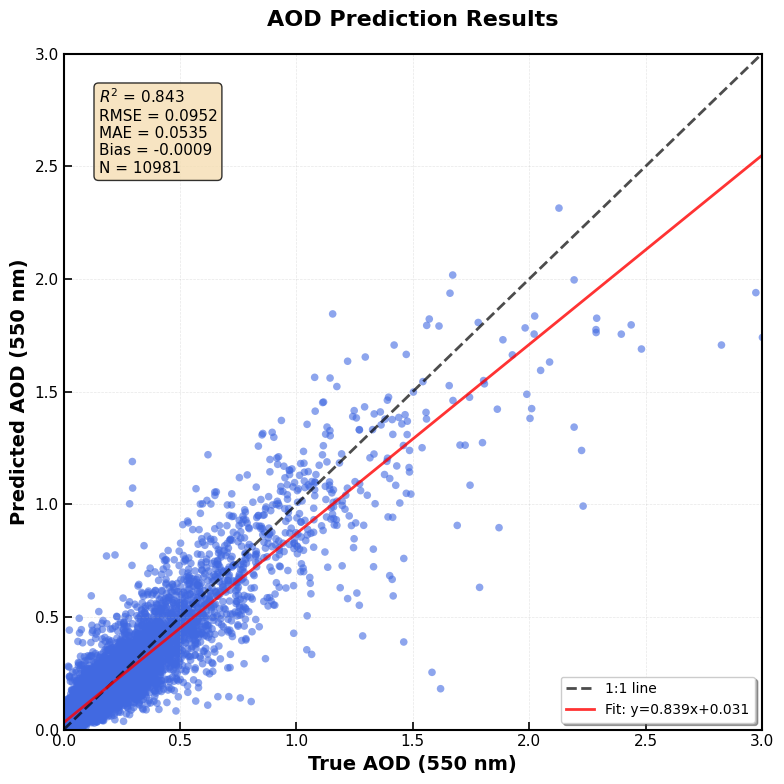

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

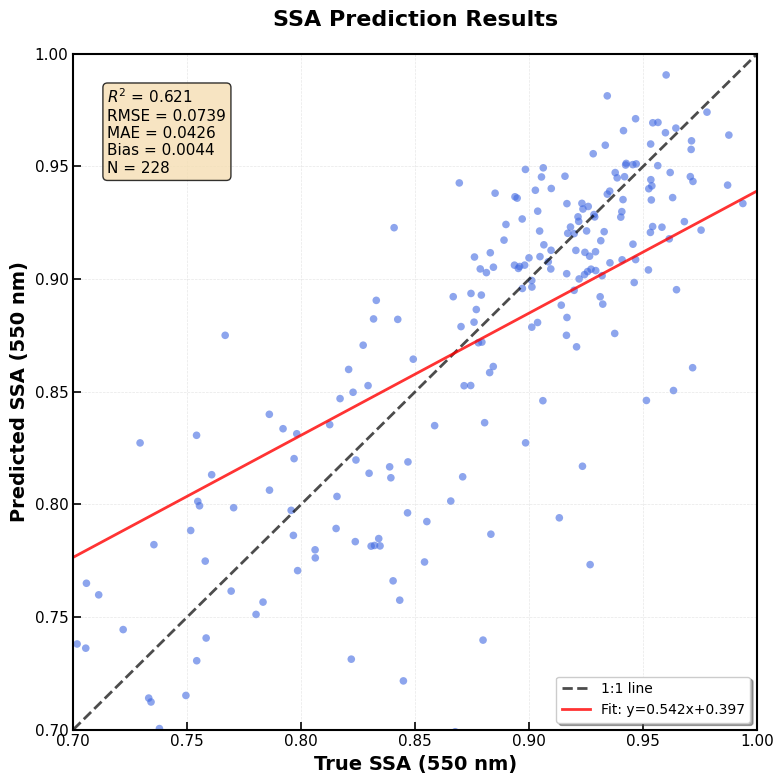

In [25]:
# ==============================================================================
# 7. 可视化结果 
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 读取数据
df = pd.read_csv(OUTPUT_CSV_PATH)

# 设置专业绘图风格
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2

# 定义绘图函数
def plot_scatter_with_stats(x, y, xlabel, ylabel, title, save_path=None, xlim=None, ylim=None):
    """
    绘制带统计信息的散点图
    
    Parameters:
    -----------
    x, y : array-like
        真实值和预测值
    xlabel, ylabel : str
        x轴和y轴标签
    title : str
        图标题
    save_path : str, optional
        保存路径
    xlim, ylim : tuple, optional
        坐标轴范围
    """
    # 过滤无效数据
    mask = (x > 0) & (y > 0) & ~np.isnan(x) & ~np.isnan(y)
    x_clean = x[mask]
    y_clean = y[mask]
    
    # 计算统计指标
    r2 = r2_score(x_clean, y_clean)
    rmse = np.sqrt(mean_squared_error(x_clean, y_clean))
    mae = mean_absolute_error(x_clean, y_clean)
    bias = np.mean(y_clean - x_clean)
    
    # 线性拟合
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # 绘制散点图
    sc = ax.scatter(x_clean, y_clean, c='royalblue', alpha=0.6, s=30, edgecolors='none', rasterized=True)
    
    # 绘制1:1参考线
    lims = [min(ax.get_xlim(), ax.get_ylim()), max(ax.get_xlim(), ax.get_ylim())]
    if xlim is not None:
        lims = xlim
    elif ylim is not None:
        lims = ylim
    else:
        min_val = min(x_clean.min(), y_clean.min())
        max_val = max(x_clean.max(), y_clean.max())
        lims = [min_val, max_val]
    
    ax.plot(lims, lims, 'k--', linewidth=2, alpha=0.7, label='1:1 line')
    
    # 绘制拟合线
    x_fit = np.array(lims)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, 'r-', linewidth=2, alpha=0.8, label=f'Fit: y={slope:.3f}x+{intercept:.3f}')
    
    # 添加统计信息文本框
    stats_text = f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.4f}\nMAE = {mae:.4f}\nBias = {bias:.4f}\nN = {len(x_clean)}'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
            fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # 设置坐标轴
    ax.set_xlabel(xlabel, fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    
    # 设置坐标轴范围
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    
    # 设置刻度
    ax.tick_params(axis='both', which='major', labelsize=11, width=1.2, length=6)
    ax.tick_params(axis='both', which='minor', width=0.8, length=3)
    
    # 添加网格（可选）
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # 图例
    ax.legend(loc='lower right', fontsize=10, frameon=True, fancybox=True, shadow=True)
    
    # 紧凑布局
    plt.tight_layout()
    
    # # 保存图片
    # if save_path:
    #     plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    #     print(f"图片已保存至: {save_path}")
    
    plt.show()
    
    return fig, ax

# 绘制AOD预测结果
fig1, ax1 = plot_scatter_with_stats(
    x=df['aeronet_AOD_565nm'],
    y=df['Pred_AOD_550nm'],
    xlabel='True AOD (550 nm)',
    ylabel='Predicted AOD (550 nm)',
    title='AOD Prediction Results',
    save_path='AOD_prediction_scatter.png',
    xlim=[0, 3],
    ylim=[0, 3]
)

# 绘制SSA预测结果
# 过滤SSA有效值（通常SSA在0-1之间）
df_ssa = df[(df['SSA_565nm'] > 0) & (df['SSA_565nm'] < 1) & 
            (df['Pred_SSA_550nm'] > 0) & (df['Pred_SSA_550nm'] < 1)]

fig2, ax2 = plot_scatter_with_stats(
    x=df_ssa['SSA_565nm'],
    y=df_ssa['Pred_SSA_550nm'],
    xlabel='True SSA (550 nm)',
    ylabel='Predicted SSA (550 nm)',
    title='SSA Prediction Results',
    save_path='SSA_prediction_scatter.png',
    xlim=[0.7, 1.0],  # SSA典型范围
    ylim=[0.7, 1.0]
)



In [27]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. 定义与训练时结构完全相同的模型类
# ==============================================================================
class DualStreamMultiHeadTransformer(nn.Module):
    def __init__(self, static_dim=1, rad_dim=9, pol_dim=6, num_angles=11, d_model=128, nhead=8, num_layers=4):
        super(DualStreamMultiHeadTransformer, self).__init__()
        self.static_emb = nn.Linear(static_dim, d_model)
        
        self.rad_emb = nn.Linear(rad_dim, d_model)
        self.cls_token_rad = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_emb_rad = nn.Parameter(torch.randn(1, num_angles + 1, d_model))
        encoder_layer_rad = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*4, dropout=0.1, batch_first=True)
        self.transformer_rad = nn.TransformerEncoder(encoder_layer_rad, num_layers=num_layers)
        
        self.pol_emb = nn.Linear(pol_dim, d_model)
        self.cls_token_pol = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_emb_pol = nn.Parameter(torch.randn(1, num_angles + 1, d_model))
        encoder_layer_pol = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*4, dropout=0.1, batch_first=True)
        self.transformer_pol = nn.TransformerEncoder(encoder_layer_pol, num_layers=num_layers)
        
        self.head_aod = nn.Sequential(nn.Linear(d_model*2, 64), nn.GELU(), nn.Dropout(0.1), nn.Linear(64, 1))
        self.head_ssa = nn.Sequential(nn.Linear(d_model*2, 64), nn.GELU(), nn.Dropout(0.1), nn.Linear(64, 1))

    def forward(self, static, rad, pol):
        b_size = rad.size(0)
        static_proj = self.static_emb(static).unsqueeze(1) 
        
        x_rad = self.rad_emb(rad)
        x_rad = torch.cat((self.cls_token_rad.expand(b_size, -1, -1) + static_proj, x_rad), dim=1) + self.pos_emb_rad
        out_rad = self.transformer_rad(x_rad)[:, 0, :] 
        
        x_pol = self.pol_emb(pol)
        x_pol = torch.cat((self.cls_token_pol.expand(b_size, -1, -1) + static_proj, x_pol), dim=1) + self.pos_emb_pol
        out_pol = self.transformer_pol(x_pol)[:, 0, :] 
        
        fused_features = torch.cat((out_rad, out_pol), dim=1) 
        return torch.cat((self.head_aod(fused_features), self.head_ssa(fused_features)), dim=1)

# ==============================================================================
# 2. 配置路径
# ==============================================================================
INPUT_CSV_PATH = '/media/amers/SSD_part1/whx/ResNet_forPolder/polder_aeronet_matched_dataset_ready_9pixel.csv'
OUTPUT_CSV_PATH = '/media/amers/SSD_part1/whx/ResNet_forPolder/polder_aeronet_matched_dataset_withPrior_9pixel.csv'

# 注意：训练代码把模型和 Scaler 全存在了这一个 .pth 文件里
MODEL_CHECKPOINT_PATH = '/media/amers/SSD_part1/whx/ResNet_forPolder/dynamic_prior/finetuned_dual_stream_transformer.pth' # 请替换为你的实际保存路径

# ==============================================================================
# 3. 加载模型和 4 个 Scalers
# ==============================================================================
print(f"\n{'='*20} 准备阶段：加载模型和Scalers {'='*20}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 加载 Checkpoint 字典
checkpoint = torch.load(MODEL_CHECKPOINT_PATH, map_location=device, weights_only=False)

# 实例化模型并加载权重
vc_model = DualStreamMultiHeadTransformer(static_dim=1, rad_dim=9, pol_dim=6, num_angles=11).to(device)
vc_model.load_state_dict(checkpoint['model_state_dict'])
vc_model.eval()

# 提取 4 个 Scaler
scaler_static = checkpoint['scaler_static']
scaler_rad = checkpoint['scaler_rad']
scaler_pol = checkpoint['scaler_pol']
scaler_y = checkpoint['scaler_y']

print("Dual-Stream 模型及 4 个 Scalers 加载成功！")

# ==============================================================================
# 4. 读取数据并提取双流特征
# ==============================================================================
print(f"\n{'='*20} 开始处理 CSV 数据 {'='*20}")
try:
    df = pd.read_csv(INPUT_CSV_PATH)
    print(f"成功读取 CSV 文件，共 {len(df)} 条记录。")
except FileNotFoundError:
    print(f"错误：找不到文件 {INPUT_CSV_PATH}！")
    exit()

# 分别存放三种特征的列表
list_static = []
list_rad = []
list_pol = []

for index, row in tqdm(df.iterrows(), total=len(df), desc="提取特征"):
    # 1. 静态特征
    elev_km = row['elev']     #这里单位是m！！
    list_static.append([elev_km])
    
    rad_row = []
    pol_row = []
    
    # 2. 角度特征：循环 ang0 到 ang10
    for ang_idx in range(11):
        sza = row.get(f'sza_ang{ang_idx}')
        
        # 缺失值填充
        if pd.isna(sza) or sza <= 0:
            rad_row.extend([0.0] * 9)
            pol_row.extend([0.0] * 6)
            continue
            
        vza = row.get(f'vza_ang{ang_idx}', 0.0)
        phi = row.get(f'phi_ang{ang_idx}', 0.0)
        
        cos_sza = np.cos(np.deg2rad(sza))
        if cos_sza < 1e-6: cos_sza = 1.0
            
        # 强度特征 (TOA)
        I443 = row.get(f'I443_ang{ang_idx}', 0.0)
        TOA443 = I443 / cos_sza if pd.notna(I443) and I443 > 0 else 0.0
        
        I565 = row.get(f'I565_ang{ang_idx}', 0.0)
        TOA565 = I565 / cos_sza if pd.notna(I565) and I565 > 0 else 0.0
        
        I1020 = row.get(f'I1020_ang{ang_idx}', 0.0)
        TOA1020 = I1020 / cos_sza if pd.notna(I1020) and I1020 > 0 else 0.0
        
        # 偏振特征 (TOA & DOLP)
        def get_toa_dolp(wl):
            I = row.get(f'I{wl}_ang{ang_idx}')
            Q = row.get(f'Q{wl}_ang{ang_idx}')
            U = row.get(f'U{wl}_ang{ang_idx}')
            if pd.isna(I) or I <= 1e-6: return 0.0, 0.0
            Q_val = Q if pd.notna(Q) else 0.0
            U_val = U if pd.notna(U) else 0.0
            return I / cos_sza, np.sqrt(Q_val**2 + U_val**2) / I

        TOA490, DOLP490 = get_toa_dolp('490')
        TOA670, DOLP670 = get_toa_dolp('670')
        TOA865, DOLP865 = get_toa_dolp('865')
        
        # 严格按照训练时的顺序追加
        rad_row.extend([sza, vza, phi, TOA443, TOA490, TOA565, TOA670, TOA865, TOA1020])
        pol_row.extend([sza, vza, phi, DOLP490, DOLP670, DOLP865])
        
    list_rad.append(rad_row)
    list_pol.append(pol_row)

# ==============================================================================
# 5. 特征缩放与形状重构 (核心修复区)
# ==============================================================================
print(f"\n{'='*20} 开始特征缩放与模型推理 {'='*20}")

# 转换为 numpy 数组
X_stat_np = np.array(list_static)  # Shape: (N, 1)
X_rad_np = np.array(list_rad)      # Shape: (N, 99)
X_pol_np = np.array(list_pol)      # Shape: (N, 66)

# 使用各自的 Scaler 进行标准化
X_stat_scaled = scaler_static.transform(X_stat_np)
X_rad_scaled = scaler_rad.transform(X_rad_np)
X_pol_scaled = scaler_pol.transform(X_pol_np)

# 重塑为 Transformer 需要的 3D 张量: (Batch, 11角度, 特征数)
X_rad_scaled = X_rad_scaled.reshape(-1, 11, 9)
X_pol_scaled = X_pol_scaled.reshape(-1, 11, 6)

# 转换为 Tensor 并送入设备
stat_tensor = torch.from_numpy(X_stat_scaled).float().to(device)
rad_tensor = torch.from_numpy(X_rad_scaled).float().to(device)
pol_tensor = torch.from_numpy(X_pol_scaled).float().to(device)

# ==============================================================================
# 6. 模型推理
# ==============================================================================
# 由于数据量可能很大，使用批处理推理防止显存/内存溢出
batch_size = 1024
all_preds = []

with torch.no_grad():
    for i in range(0, len(stat_tensor), batch_size):
        stat_b = stat_tensor[i:i+batch_size]
        rad_b = rad_tensor[i:i+batch_size]
        pol_b = pol_tensor[i:i+batch_size]
        
        # 必须传入三个参数
        preds = vc_model(stat_b, rad_b, pol_b)
        all_preds.append(preds.cpu().numpy())

y_pred_scaled = np.vstack(all_preds)

# 反归一化
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# 物理约束
y_pred[:, 0] = np.clip(y_pred[:, 0], 0.0, None)  # AOD >= 0
y_pred[:, 1] = np.clip(y_pred[:, 1], 0.0, 1.0)   # 0 <= SSA <= 1

# ==============================================================================
# 7. 保存结果到 DataFrame
# ==============================================================================
# 目标列是 ['AOD_550nm', 'SSA_550nm']，索引分别是 0 和 1
df['Pred_AOD_550nm'] = y_pred[:, 0]
df['Pred_SSA_550nm'] = y_pred[:, 1]

df.to_csv(OUTPUT_CSV_PATH, index=False)
print(f"\n推理完成！结果已成功保存至：\n{OUTPUT_CSV_PATH}")


==================== 准备阶段：加载模型和Scalers ====================
Dual-Stream 模型及 4 个 Scalers 加载成功！

==================== 开始处理 CSV 数据 ====================
成功读取 CSV 文件，共 28488 条记录。


提取特征: 100%|██████████| 28488/28488 [00:13<00:00, 2170.27it/s]



==================== 开始特征缩放与模型推理 ====================

推理完成！结果已成功保存至：
/media/amers/SSD_part1/whx/ResNet_forPolder/polder_aeronet_matched_dataset_withPrior_9pixel.csv
